<a href="https://colab.research.google.com/github/BrianaNzivu/Scancer/blob/main/Scancer_DetectorQuestionare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier

In [18]:
df = pd.read_csv('/content/bcsc_risk_factors_summarized1_092020.csv')
print(df.columns)

Index(['year', 'age_group_5_years', 'race_eth', 'first_degree_hx',
       'age_menarche', 'age_first_birth', 'BIRADS_breast_density',
       'current_hrt', 'menopaus', 'bmi_group', 'biophx',
       'breast_cancer_history', 'count'],
      dtype='object')


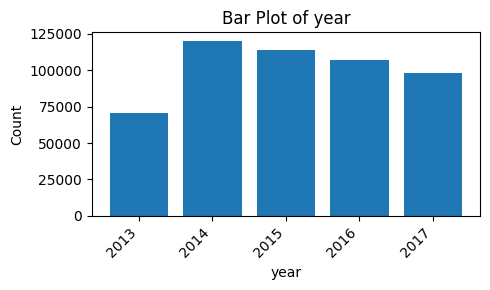

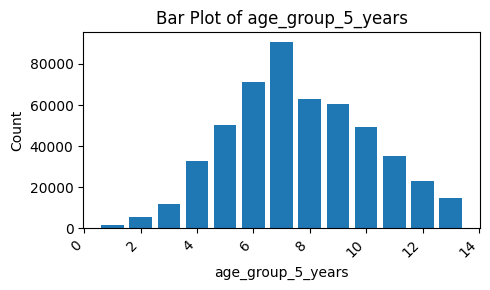

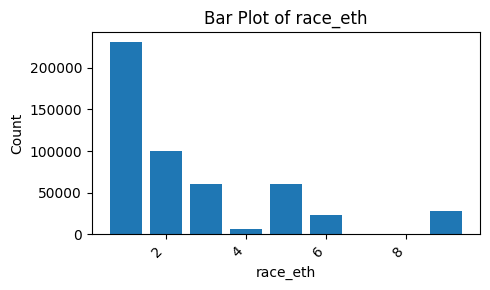

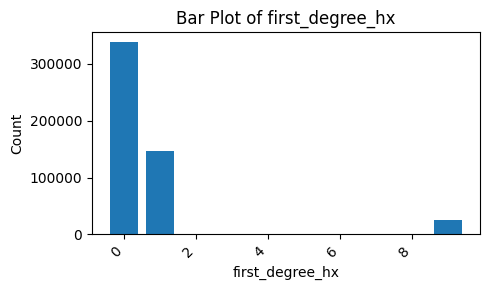

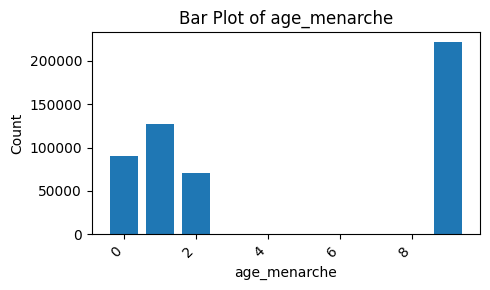

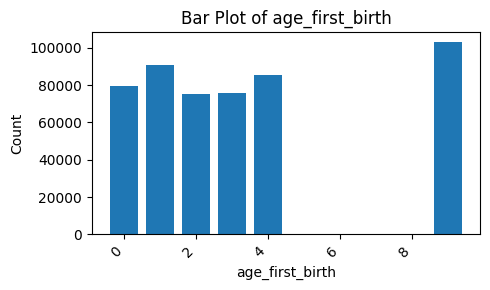

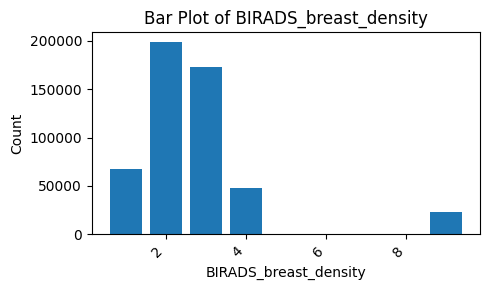

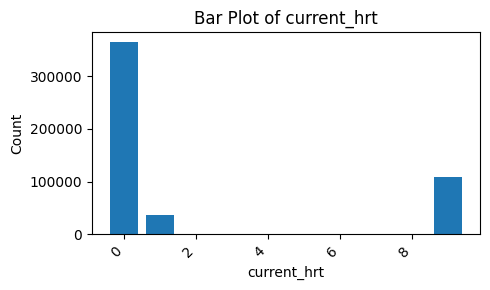

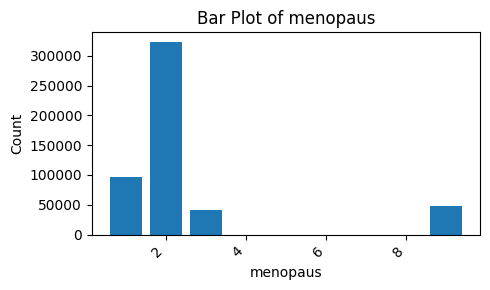

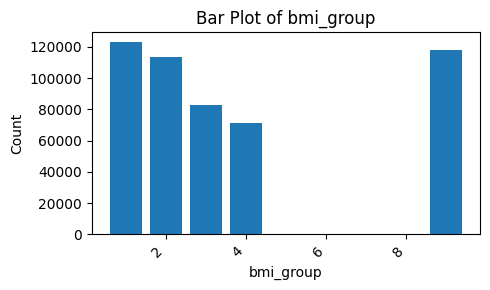

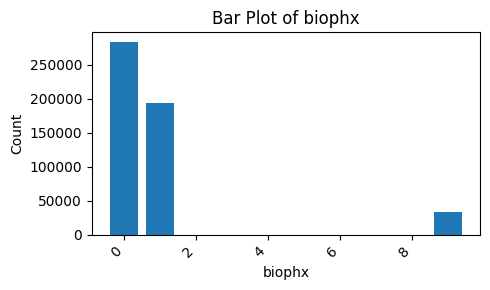

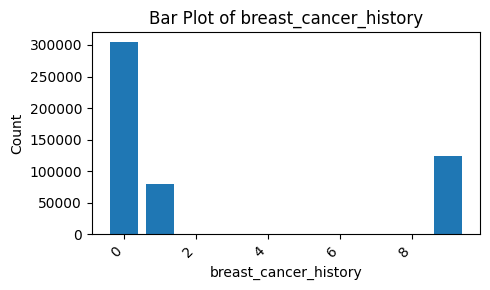

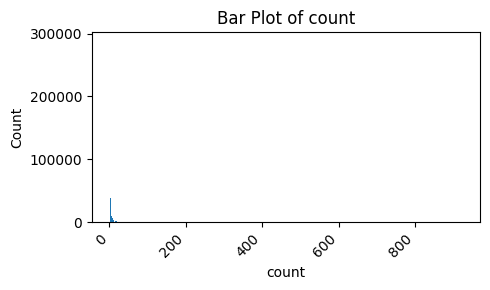

In [19]:
for column in df.columns:
  plt.figure(figsize=(5,3))
  plt.bar(df[column].value_counts().index, df[column].value_counts())
  plt.xlabel(column)
  plt.ylabel('Count')
  plt.title(f'Bar Plot of {column}')
  plt.xticks(rotation=45, ha='right')
  plt.tight_layout()

In [20]:
# Feature Engineering
# Handling Missing Values
df.isnull().sum()

year                     0
age_group_5_years        0
race_eth                 0
first_degree_hx          0
age_menarche             0
age_first_birth          0
BIRADS_breast_density    0
current_hrt              0
menopaus                 0
bmi_group                0
biophx                   0
breast_cancer_history    0
count                    0
dtype: int64

In [24]:
#Comparing Algorithms to see which one performs better. Comparison between ecision Tree and Logisic Regression
# Logistic Regression
# Assuming 'df' is your DataFrame and 'count' is included
X = df.drop('breast_cancer_history', axis=1)
y = df['breast_cancer_history']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train logistic regression model
logreg_model = LogisticRegression(max_iter=1000)  # Increase as needed
logreg_model.fit(X_train, y_train)

# Predict on test set
y_pred_logreg = logreg_model.predict(X_test)

# Evaluate model performance
print("Logistic Regression:")
print("Accuracy:", accuracy_score(y_test, y_pred_logreg))
print(classification_report(y_test, y_pred_logreg))

Logistic Regression:
Accuracy: 0.6721992108517697
              precision    recall  f1-score   support

           0       0.70      0.89      0.78     61195
           1       0.31      0.03      0.06     16019
           9       0.60      0.54      0.57     24668

    accuracy                           0.67    101882
   macro avg       0.54      0.49      0.47    101882
weighted avg       0.61      0.67      0.62    101882



In [22]:
# Train decision tree model
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)

# Predict on test set
y_pred_tree = tree_model.predict(X_test)

# Evaluate model performance
print("\nDecision Tree:")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))


Decision Tree:
Accuracy: 0.6967177715396242
              precision    recall  f1-score   support

           0       0.79      0.79      0.79     61195
           1       0.41      0.43      0.42     16019
           9       0.66      0.63      0.65     24668

    accuracy                           0.70    101882
   macro avg       0.62      0.62      0.62    101882
weighted avg       0.70      0.70      0.70    101882

